In [41]:
# importing libraries
import numpy as np 
import matplotlib.pyplot as plt 

#### Part(a)

Given that 
$$
f(\omega, \theta) = \dfrac{cos\omega cos\theta + sin\omega sin\theta - 1}{4(cos\omega - cos\theta)^2 + (sin\omega - sin\theta)^2}
$$
On Multiplying and dividing by -2 in Numerator and Denomenator

\begin{equation*}
\begin{aligned}
f(\omega, \theta) & = -\dfrac{1}{2} \cdot \dfrac{-2\cos\omega \cos\theta - 2 \sin\omega \cos\theta + 1 + 1}{4(\cos\omega - \cos\theta)^2 + (\sin\omega - \sin\theta)^2} \\
                  & = -\dfrac{1}{2} \cdot \dfrac{-2\cos\omega \cos\theta - 2 \sin\omega \cos\theta + cos^2\omega + sin^2\omega + cos^2\theta + sin^2\theta }{4(\cos\omega - \cos\theta)^2 + (\sin\omega - \sin\theta)^2} \\
                  & = -\dfrac{1}{2} \cdot \dfrac{(\cos\omega - \cos\theta)^2 + (\sin\omega - \sin\theta)^2}{4(\cos\omega - \cos\theta)^2 + (\sin\omega - \sin\theta)^2} \\
                  & = -\dfrac{1}{2} \cdot \dfrac{1}{4 - 3 cos^2\left(\dfrac{\omega + \theta}{2}\right)} \\
\end{aligned}
\end{equation*}

On applying limits,

\begin{equation*}
\begin{aligned}
f(\omega, \theta) & = \dfrac{1}{2\left( 3cos^2\theta - 4 \right)} \\
\end{aligned}
\end{equation*}




### Part(b)

In [42]:
# defining the function f(omega , theta)
def f(omega, theta):
    if omega == theta: 
        return 1/(2 * (3*np.power(np.cos(theta), 2) - 4))
    else :
        return (np.cos(omega)*np.cos(theta) + np.sin(omega)*np.sin(theta) - 1)/( 4*(np.cos(omega) - np.cos(theta))**2 + (np.sin(omega) - np.sin(theta))**2)


In [43]:
# defining the function for matrix
def matrix(N):
    delta_theta = 2*np.pi/N 
    A = np.empty((N, N))

    for i in range(N):
        for j in range(N):
            omega_i = (i + 1) * delta_theta
            omega_j = (j + 1) * delta_theta
            A[i, j] = f(omega_i, omega_j )
    
    return A         

In [44]:
# Testing the functions
matrix(5)

array([[-0.13464294, -0.13464294, -0.24552235, -0.5       , -0.24552235],
       [-0.13464294, -0.24552235, -0.5       , -0.24552235, -0.13464294],
       [-0.24552235, -0.5       , -0.24552235, -0.13464294, -0.13464294],
       [-0.5       , -0.24552235, -0.13464294, -0.13464294, -0.24552235],
       [-0.24552235, -0.13464294, -0.13464294, -0.24552235, -0.5       ]])

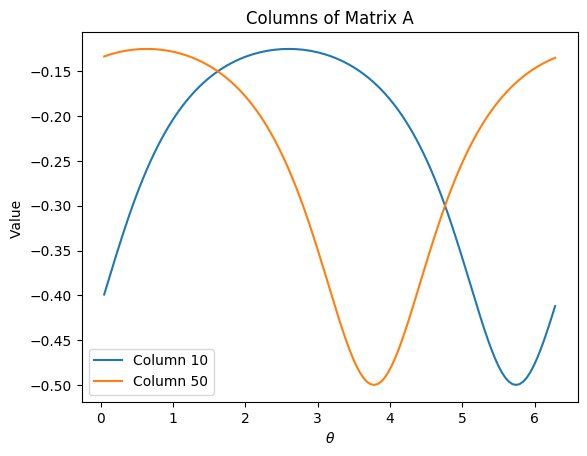

Matrix A is symmetric: True


In [45]:
def plot_columns(matrix, col_indices):
    '''----------------------------------------------------------------
    Function to plot the columns of a matrix
    
    Parameters:
    matrix - matrix whose columns are to be plotted
    col_indices - indices of the columns to be plotted 
    ---------------------------------------------------------------- '''
    N = matrix.shape[0]
    theta_values = np.linspace(2 * np.pi / N, 2 * np.pi, N)

    for col_index in col_indices:
        plt.plot(theta_values, matrix[:, col_index], label=f"Column {col_index}")

    plt.xlabel(r"$\theta$")
    plt.ylabel("Value ")
    plt.title("Columns of Matrix A")
    plt.legend()
    plt.show()

def check_symmetric(matrix):
    '''--------------------------------------
    Function to check if matrix is symmetric
    -----------------------------------------'''
    return np.allclose(matrix, matrix.T)

N = 128
matrix_A = matrix(N)

# Plot the 10th and 50th columns of matrix A
plot_columns(matrix_A, [10, 50])

# Check if matrix A is symmetric
is_symmetric = check_symmetric(matrix_A)
print("Matrix A is symmetric:", is_symmetric)

#### Contour Plot of Matrix

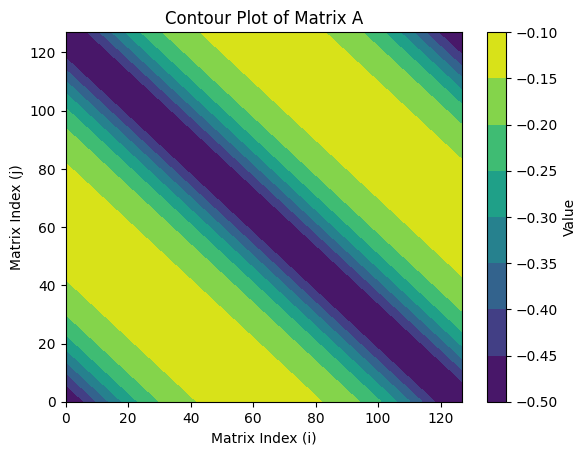

In [46]:
def plot_matrix_contour(matrix):
    N = matrix.shape[0]
    indices = np.arange(N)

    # Create a meshgrid for matrix indices
    x, y = np.meshgrid(indices, indices)

    # Create a contour plot of the matrix
    plt.contourf(x, y, matrix, cmap='viridis')
    plt.colorbar(label='Value')
    plt.xlabel("Matrix Index (i)")
    plt.ylabel("Matrix Index (j)")
    plt.title("Contour Plot of Matrix A")
    plt.show()

N = 128
matrix_A = matrix(N)

# Plot the contour plot of the entire matrix A with matrix indices on axes
plot_matrix_contour(matrix_A)


In [47]:
def nofsingular(A, k, N):
    '''---------------------------------------------------------
    Function to count number of singular values in each block
    ---------------------------------------------------------'''
    TOL = 1e-12
    Sol = np.zeros((k, k))
    dn = N // k

    for s in range(k):
        for h in range(k):
            S = np.linalg.svd(A[dn * s: dn * (s + 1), dn * h: dn * (h + 1)], compute_uv=False)
            number = np.sum(S > TOL)
            Sol[s, h] = number

    return Sol

In [48]:
# Varying N and k
N_values = [2048, 4096, 8192]
k_values = [2, 4, 8]

for N in N_values:
    print("------------------------")
    print(f"    For N = {N}:")
    print("------------------------")
    matrix_A = matrix(N)
    for k in k_values:
        print(f"k = {k}:")
        result = nofsingular(matrix_A, k, N)
        print("\n",result, "\n")

------------------------
    For N = 2048:
------------------------
k = 2:

 [[734.  38.]
 [ 38. 744.]] 

k = 4:

 [[364.  11.  15.  21.]
 [ 11. 371.  21.  15.]
 [ 15.  21. 377.  11.]
 [ 21.  15.  11. 367.]] 

k = 8:

 [[209.   8.   8.   7.   8.   8.  11.  13.]
 [  8. 153.   7.   8.   8.  11.  12.  11.]
 [  8.   7. 160.   9.  11.  12.  11.   8.]
 [  7.   8.   9. 212.  13.  11.   8.   8.]
 [  8.   8.  11.  13. 213.   9.   8.   7.]
 [  8.  11.  12.  11.   9. 163.   7.   8.]
 [ 11.  12.  11.   8.   8.   7. 153.   8.]
 [ 13.  11.   8.   8.   7.   8.   8. 213.]] 

------------------------
    For N = 4096:
------------------------
k = 2:

 [[1959.   41.]
 [  41. 1951.]] 

k = 4:

 [[980.  13.  15.  23.]
 [ 13. 979.  23.  15.]
 [ 15.  23. 981.  13.]
 [ 23.  15.  13. 968.]] 

k = 8:

 [[497.  10.   8.   7.   8.   8.  11.  15.]
 [ 10. 482.   9.   8.   8.  11.  13.  11.]
 [  8.   9. 479.  11.  11.  13.  11.   8.]
 [  7.   8.  11. 500.  15.  11.   8.   8.]
 [  8.   8.  11.  15. 494.  10.   8.   